<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/Genetic_Algorithm_Knapsack_PyGAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання. Генетичний алгоритм для задачі про рюкзак

**Курс:** Numerical Programming in Python  
**Тема 11:** Евристичні методи оптимізації. Генетичні алгоритми

У роботі розв’язується задача про рюкзак для 14 товарів за допомогою бібліотеки `PyGAD`.

Мета — максимізувати сумарну цінність вибраних товарів за умови, що їх загальна вага не перевищує місткість рюкзака.

**Обраний підхід до здачі:** намагатися отримати вищий бал шляхом можливого доопрацювання роботи відповідно до фідбеку ментора.


## 1. Встановлення та імпорт бібліотек

In [1]:
!pip -q install pygad

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pygad

np.random.seed(42)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.3/218.3 kB 3.8 MB/s eta 0:00:00


## 2. Початкові дані

Кожен товар має:

- назву;
- вагу;
- цінність.

Хромосома складається з 14 бінарних генів:

- `1` — товар покладено в рюкзак;
- `0` — товар не вибрано.


In [2]:
items = pd.DataFrame({
    "Item": [
        "Item 1", "Item 2", "Item 3", "Item 4",
        "Item 5", "Item 6", "Item 7", "Item 8",
        "Item 9", "Item 10", "Item 11", "Item 12",
        "Item 13", "Item 14"
    ],
    "Weight": [7, 3, 4, 5, 8, 6, 2, 9, 1, 4, 7, 3, 5, 6],
    "Value":  [42, 12, 40, 25, 50, 35, 10, 60, 8, 30, 45, 18, 28, 38]
})

capacity = 30

display(items)
print("Місткість рюкзака:", capacity)


,Item,Weight,Value
0,Item 1,7,42
1,Item 2,3,12
2,Item 3,4,40
3,Item 4,5,25
4,Item 5,8,50
5,Item 6,6,35
6,Item 7,2,10
7,Item 8,9,60
8,Item 9,1,8
9,Item 10,4,30


Місткість рюкзака: 30


## 3. Фітнес-функція

Фітнес дорівнює сумарній цінності вибраних товарів.

Якщо загальна вага перевищує місткість рюкзака, до фітнесу застосовується великий штраф. Це змушує генетичний алгоритм уникати некоректних рішень.


In [3]:
weights = items["Weight"].to_numpy()
values = items["Value"].to_numpy()

def fitness_function(ga_instance, solution, solution_idx):
    solution = np.asarray(solution, dtype=int)

    total_weight = np.sum(solution * weights)
    total_value = np.sum(solution * values)

    if total_weight <= capacity:
        return float(total_value)

    penalty = 1000 + 50 * (total_weight - capacity)
    return float(total_value - penalty)


## 4. Початкова популяція

In [4]:
num_genes = len(items)
population_size = 30

initial_population = np.random.randint(
    0,
    2,
    size=(population_size, num_genes)
)

print("Розмір початкової популяції:", initial_population.shape)
print("Перші 5 хромосом:")
print(initial_population[:5])


Розмір початкової популяції: (30, 14)
Перші 5 хромосом:
[[0 1 0 0 0 1 0 0 0 1 0 0 0 0]
 [1 0 1 1 1 0 1 0 1 1 1 1 1 1]
 [1 1 0 0 1 1 1 0 1 0 0 0 0 0]
 [1 1 1 1 1 0 1 1 0 1 0 1 0 1]
 [1 0 0 0 0 0 0 0 0 1 1 0 1 1]]


## 5. Допоміжна функція запуску PyGAD

Функція запускає генетичний алгоритм із заданими типами кросовера та мутації і повертає найкраще рішення.


In [5]:
def run_ga(
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=10,
    num_generations=200,
    random_seed=42
):
    ga_instance = pygad.GA(
        num_generations=num_generations,
        num_parents_mating=12,
        fitness_func=fitness_function,
        sol_per_pop=population_size,
        num_genes=num_genes,
        initial_population=initial_population.copy(),
        gene_type=int,
        gene_space=[0, 1],
        parent_selection_type="sss",
        keep_parents=2,
        crossover_type=crossover_type,
        mutation_type=mutation_type,
        mutation_percent_genes=mutation_percent_genes,
        stop_criteria=["saturate_50"],
        random_seed=random_seed,
        suppress_warnings=True
    )

    ga_instance.run()

    solution, fitness, solution_idx = ga_instance.best_solution()
    solution = np.asarray(solution, dtype=int)

    total_weight = int(np.sum(solution * weights))
    total_value = int(np.sum(solution * values))

    return {
        "ga_instance": ga_instance,
        "solution": solution,
        "fitness": float(fitness),
        "total_weight": total_weight,
        "total_value": total_value,
        "selected_items": items.loc[solution == 1].copy()
    }


## 6. Базовий запуск генетичного алгоритму

In [6]:
baseline_result = run_ga(
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=10
)

print("Найкраща хромосома:")
print(baseline_result["solution"])

print("\nЗагальна вага:", baseline_result["total_weight"])
print("Загальна цінність:", baseline_result["total_value"])

print("\nВибрані товари:")
display(baseline_result["selected_items"])


Найкраща хромосома:
[0 0 1 0 0 0 0 1 0 1 1 0 0 1]

Загальна вага: 30
Загальна цінність: 213

Вибрані товари:


,Item,Weight,Value
2,Item 3,4,40
7,Item 8,9,60
9,Item 10,4,30
10,Item 11,7,45
13,Item 14,6,38


## 7. Графік зміни фітнесу

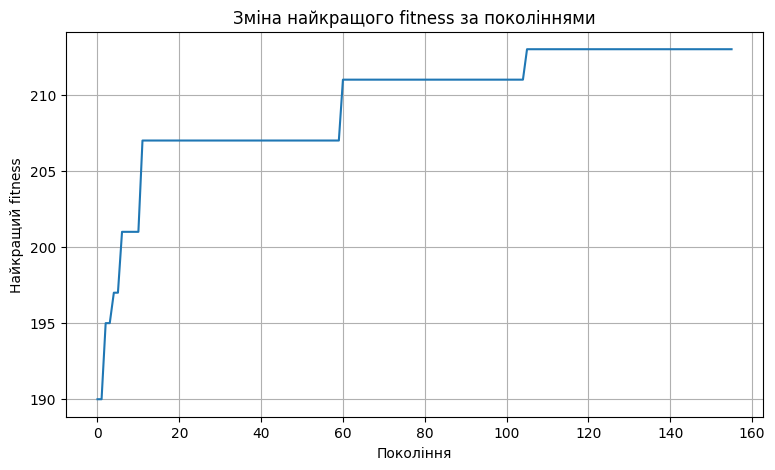

In [7]:
fitness_history = baseline_result["ga_instance"].best_solutions_fitness

plt.figure(figsize=(9, 5))
plt.plot(fitness_history)
plt.xlabel("Покоління")
plt.ylabel("Найкращий fitness")
plt.title("Зміна найкращого fitness за поколіннями")
plt.grid()
plt.show()


## 8. Дослідження різних типів кросовера та мутації

Перевіряємо кілька комбінацій параметрів:

- `single_point`;
- `two_points`;
- `uniform`;
- `scattered`;

та мутації:

- `random`;
- `swap`;
- `inversion`;
- `scramble`.


In [8]:
crossover_types = [
    "single_point",
    "two_points",
    "uniform",
    "scattered"
]

mutation_types = [
    "random",
    "swap",
    "inversion",
    "scramble"
]

experiment_results = []

for crossover in crossover_types:
    for mutation in mutation_types:
        result = run_ga(
            crossover_type=crossover,
            mutation_type=mutation,
            mutation_percent_genes=15,
            num_generations=200,
            random_seed=42
        )

        experiment_results.append({
            "Crossover": crossover,
            "Mutation": mutation,
            "Fitness": result["fitness"],
            "Total weight": result["total_weight"],
            "Total value": result["total_value"],
            "Valid": result["total_weight"] <= capacity,
            "Solution": result["solution"].tolist()
        })

experiments_df = pd.DataFrame(experiment_results)
experiments_df = experiments_df.sort_values(
    by=["Valid", "Total value"],
    ascending=[False, False]
).reset_index(drop=True)

display(experiments_df)


,Crossover,Mutation,Fitness,Total weight,Total value,Valid,Solution
0,uniform,random,213.0,30,213,True,"[0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1]"
1,scattered,random,213.0,30,213,True,"[0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1]"
2,single_point,scramble,211.0,30,211,True,"[0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1]"
3,two_points,random,211.0,30,211,True,"[0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0]"
4,two_points,scramble,211.0,30,211,True,"[0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0]"
5,uniform,inversion,211.0,30,211,True,"[0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1]"
6,uniform,scramble,211.0,30,211,True,"[0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0]"
7,scattered,inversion,211.0,30,211,True,"[0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1]"
8,scattered,scramble,211.0,30,211,True,"[0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0]"
9,single_point,random,210.0,30,210,True,"[1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1]"


## 9. Порівняння результатів експериментів

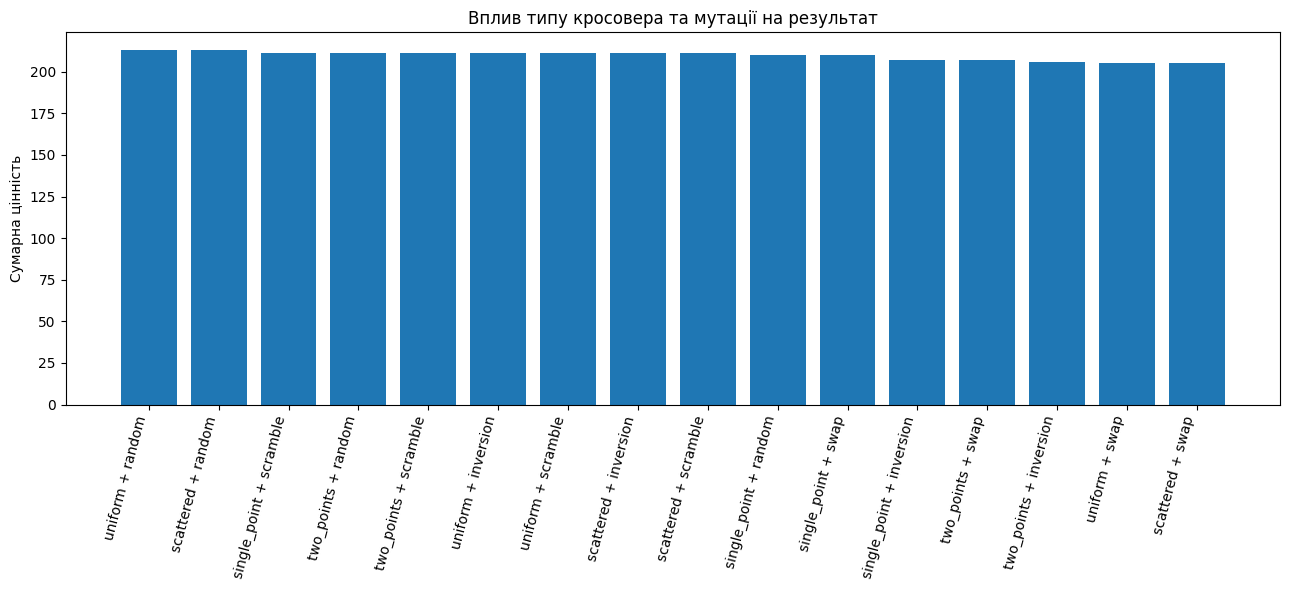

In [9]:
labels = (
    experiments_df["Crossover"]
    + " + "
    + experiments_df["Mutation"]
)

plt.figure(figsize=(13, 6))
plt.bar(labels, experiments_df["Total value"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Сумарна цінність")
plt.title("Вплив типу кросовера та мутації на результат")
plt.tight_layout()
plt.show()


## 10. Дослідження впливу інтенсивності мутації

Для найкращого типу кросовера і мутації перевіримо різний відсоток генів, які мутують.


In [10]:
best_row = experiments_df.iloc[0]
best_crossover = best_row["Crossover"]
best_mutation = best_row["Mutation"]

mutation_rates = [5, 10, 15, 20, 30, 40]
mutation_rate_results = []

for rate in mutation_rates:
    result = run_ga(
        crossover_type=best_crossover,
        mutation_type=best_mutation,
        mutation_percent_genes=rate,
        num_generations=200,
        random_seed=42
    )

    mutation_rate_results.append({
        "Mutation percent": rate,
        "Total value": result["total_value"],
        "Total weight": result["total_weight"],
        "Fitness": result["fitness"]
    })

mutation_rate_df = pd.DataFrame(mutation_rate_results)
display(mutation_rate_df)


,Mutation percent,Total value,Total weight,Fitness
0,5,213,30,213.0
1,10,213,30,213.0
2,15,213,30,213.0
3,20,213,30,213.0
4,30,210,30,210.0
5,40,211,30,211.0


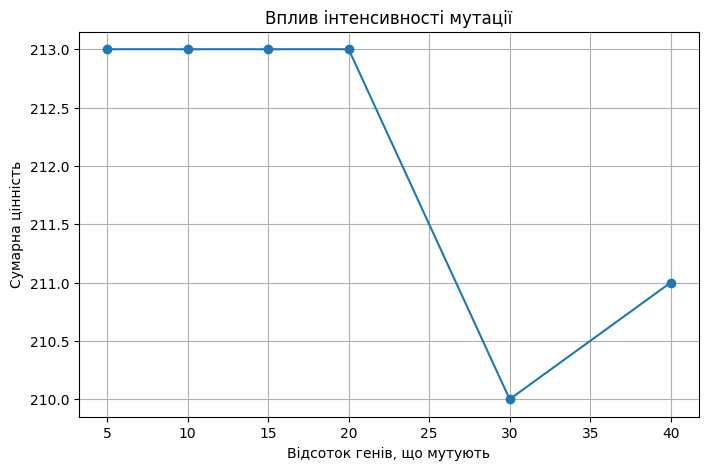

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(
    mutation_rate_df["Mutation percent"],
    mutation_rate_df["Total value"],
    marker="o"
)
plt.xlabel("Відсоток генів, що мутують")
plt.ylabel("Сумарна цінність")
plt.title("Вплив інтенсивності мутації")
plt.grid()
plt.show()


## 11. Перевірка оптимальності повним перебором

Оскільки маємо лише 14 товарів, кількість усіх можливих комбінацій становить $2^{14}=16384$. Це дозволяє знайти точний оптимум повним перебором і порівняти його з результатом генетичного алгоритму.


In [12]:
def brute_force_knapsack(weights, values, capacity):
    n = len(weights)
    best_value = -1
    best_weight = 0
    best_solution = None

    for mask in range(2 ** n):
        solution = np.array(
            [(mask >> i) & 1 for i in range(n)],
            dtype=int
        )

        total_weight = int(np.sum(solution * weights))
        total_value = int(np.sum(solution * values))

        if total_weight <= capacity and total_value > best_value:
            best_value = total_value
            best_weight = total_weight
            best_solution = solution

    return best_solution, best_weight, best_value


exact_solution, exact_weight, exact_value = brute_force_knapsack(
    weights,
    values,
    capacity
)

print("Точне оптимальне рішення:")
print(exact_solution)
print("Точна оптимальна вага:", exact_weight)
print("Точна оптимальна цінність:", exact_value)

display(items.loc[exact_solution == 1])


Точне оптимальне рішення:
[0 0 1 0 0 0 0 1 0 1 1 0 0 1]
Точна оптимальна вага: 30
Точна оптимальна цінність: 213


,Item,Weight,Value
2,Item 3,4,40
7,Item 8,9,60
9,Item 10,4,30
10,Item 11,7,45
13,Item 14,6,38


## 12. Порівняння PyGAD із точним рішенням

In [13]:
best_experiment = experiments_df.iloc[0]

print("Найкраща комбінація параметрів PyGAD:")
print("Crossover:", best_experiment["Crossover"])
print("Mutation:", best_experiment["Mutation"])
print("GA value:", best_experiment["Total value"])
print("Exact value:", exact_value)

difference = exact_value - best_experiment["Total value"]
print("Різниця з точним оптимумом:", difference)


Найкраща комбінація параметрів PyGAD:
Crossover: uniform
Mutation: random
GA value: 213
Exact value: 213
Різниця з точним оптимумом: 0


# Висновки

У роботі було реалізовано генетичний алгоритм для задачі про рюкзак із 14 товарами.

Було виконано такі кроки:

1. визначено бінарне представлення хромосоми;
2. реалізовано окрему фітнес-функцію;
3. створено початкову популяцію;
4. задано параметри генетичного алгоритму;
5. створено та запущено модель за допомогою `PyGAD`;
6. досліджено різні типи кросовера та мутації;
7. досліджено вплив інтенсивності мутації;
8. результат перевірено точним повним перебором.

Генетичний алгоритм є ефективним для задач комбінаторної оптимізації, особливо коли кількість можливих комбінацій є дуже великою і повний перебір стає занадто дорогим.

Для невеликої задачі з 14 товарами точний оптимум можна знайти повним перебором. Це дозволило перевірити якість результату PyGAD. Успішність алгоритму залежить від типу кросовера, мутації, розміру популяції, кількості поколінь та інтенсивності мутації.

Найкращим набором параметрів слід вважати ту комбінацію, яка у таблиці експериментів дала найбільшу сумарну цінність без перевищення місткості рюкзака та максимально наблизилася до точного оптимуму.
